# Setting up a latent function Gaussian Process for H(z)

In [1]:
# import set 
using Turing
using Distances
using LinearAlgebra
using LimberJack
using Interpolations
using GaussianProcess
using Plots
using QuadGK
using BlockDiagonals
using CSV
using DataFrames
using PrettyTables

### Collate data

In [2]:
# setting a cosmology for the fake data, all fiducial cosmo parameters 
cosmo1 = Cosmology();
rd_fid = 99.0792;
rd_red = 147.5;

# assumed parameter distributions
omegam_dist = Normal(0.3,0.2);
h0_dist = Uniform(0.5,0.8);
s8_dist = Normal(0.8,0.5);
rd_dist = Normal(150,5);
M_dist = Normal(-19.2, 1);

#### Generate fake data

In [3]:
# hz data
function data_hz()
    z = [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2,
        0.27, 0.28, 0.352, 0.38, 0.3802, 0.4,
        0.4004, 0.4247, 0.44, 0.4497, 0.47, 0.4783,
        0.48, 0.51, 0.593, 0.6, 0.61, 0.68, 0.73,
        0.781, 0.875, 0.88, 0.9, 1.037, 1.3,
        1.363, 1.43, 1.53, 1.75, 1.965
    ]

    data = [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
        77.0, 88.8, 83.0, 81.5, 83.0, 95.0, 77.0,
        87.1, 82.6, 92.8, 89.0, 80.9, 97.0, 90.4,
        104.0, 87.9, 97.3, 92.0, 97.3, 105.0,
        125.0, 90.0, 117.0, 154.0, 168.0, 160.0,
        177.0, 140.0, 202.0, 186.5
    ]

    err = [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
        14.0, 36.6, 14.0, 1.9, 13.5, 17.0, 10.2,
        11.2, 7.8, 12.9, 23.0, 9.0, 62.0, 1.9,
        13.0, 6.1, 2.1, 8.0, 7.0, 12.0, 17.0,
        40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
        14.0, 40.0, 50.4
    ]

    cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end

    return (
        data_name = "data_hz",
        z = z,
        data = data,
        err = err,
        cov = cov
    )
end

# fs8 data
function data_fs8()

z  = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]

data  = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]

fs8_upper = [0.4723, 0.572693, 0.539136, 0.470586, 0.418064, 0.48]
fs8_lower = [0.28338, 0.449635, 0.428544, 0.378228, 0.343128, 0.39]
err_up = fs8_upper .- data
err_low = data .- fs8_lower
err = (fs8_upper .- fs8_lower) ./ 2

cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end
    
    return (data_name = "data_fs8", z = z, data = data, err = err, cov = cov)
end

data_fs8 (generic function with 1 method)

In [4]:
datafs8 = data_fs8();

In [5]:
# correlation matrix
function cov_to_cor(covariance)
    std_devs = sqrt.(diag(covariance))
    return covariance ./ (std_devs * std_devs')
end

cov_to_cor (generic function with 1 method)

In [6]:
function data_DESI()
    # DESI data
    z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
    z = repeat(z1, inner = 3)
    data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
    data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508]
    data_fs8 = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]
    #data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    
    data = 
    [7.788174, 3.053800, 0.37784,   # BGS (z=0.30)
    12.514437, 1.637266, 0.515897, # LRG1 (z=0.51)
    15.675560, 1.165867, 0.48384,  # LRG2 (z=0.71)
    19.676985, 0.844996, 0.422208, # LRG3 (z=0.92)
    23.861806, 0.470709, 0.37468,  # ELG2 (z=1.32)
    25.708520, 0.426508, 0.435  ]   # QSO (z=1.49)

    # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
    # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
    # Source: arXiv:2411.12021 Appendix A
    C_total = zeros(18, 18);

    # BGS z=0.30
    C_total[1:3, 1:3] = 1e-4 * [
        1314.664401 -142.669742  109.427163;
        -142.669742  829.170940 -158.101737;
        109.427163 -158.101737   88.510877
    ]

    # LRG1 z=0.51
    C_total[4:6, 4:6] = 1e-4 * [
        541.309833   48.425593   -4.652853;
        48.425593   97.249820  -34.923265;
        -4.652853  -34.923265   41.295470
    ]

    # LRG2 z=0.71
    C_total[7:9, 7:9] = 1e-4 * [
        762.457717   39.781004   -1.896006;
        39.781004   36.344098  -17.341350;
        -1.896006  -17.341350   28.119682
    ]

    # LRG3 z=0.92
    C_total[10:12, 10:12] = 1e-4 * [
        847.499793   26.038900    3.257324;
        26.038900   16.251088  -10.044074;
        3.257324  -10.044074   22.370314
    ]

    # ELG2 z=1.32
    C_total[13:15, 13:15] = 1e-4 * [
    2342.506886   26.159601   13.521001;
        26.159601   10.309303   -6.654663;
        13.521001   -6.654663   13.997473
    ]

    # QSO z=1.49
    C_total[16:18, 16:18] = 1e-4 * [
    3013.788566   -2.205101   36.332110;
        -2.205101    5.845806   -6.747133;
        36.332110   -6.747133   19.785658
    ]

    full_covariance = cov_to_cor(C_total);

    cov_final = C_total
    for k in 1:6
        cov_final[3*k,3*k] = datafs8.cov[k,k]
    end

    for h in 1:6
        cov_final[(3*h)-2,3*h] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-2,(3*h)-2]) * full_covariance[(3*h)-2,3*h]
        cov_final[(3*h)-1,3*h] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-1,(3*h)-1]) * full_covariance[(3*h)-1,3*h]
        cov_final[3*h,(3*h)-2] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-2,(3*h)-2]) * full_covariance[(3*h)-2,3*h]
        cov_final[3*h,(3*h)-1] = sqrt(cov_final[3*h,3*h] * C_total[(3*h)-1,(3*h)-1]) * full_covariance[(3*h)-1,3*h]
    end
    
    cov = cov_final
    
    err_arr = sqrt.(diag(cov))
    err_dvrd = err_arr[1:3:end]
    err_dhdm = err_arr[2:3:end]
    err_fs8 = err_arr[3:3:end]

    return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fs8 = data_fs8, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fs8 = err_fs8, cov = cov)
end

data_DESI (generic function with 1 method)

In [7]:
dataDESI = data_DESI();
datahz = data_hz();

In [8]:
# Load data
supernovae_raw = CSV.read("DES_Dovekie_HD.csv", DataFrame);
# Find indices that satisfy the condition
keep_idx = findall(supernovae_raw.MUERR .< 1);
# Filter the dataframe
supernovae = supernovae_raw[keep_idx, :];
# Load covariance matrix
supernovae_cov_df = CSV.read("STAT+SYS_dovekie.csv", DataFrame);
supernovae_cov = Matrix(supernovae_cov_df);
# Filter covariance matrix (rows AND columns)
sup_cov_filt = supernovae_cov[keep_idx, keep_idx];

function data_mu()

    z = supernovae[!,"zHD"][1:30:end]
    z_hel = supernovae[!,"zHEL"][1:30:end]
    data = supernovae[!,"MU"][1:30:end]

    cov = Symmetric(sup_cov_filt[1:30:end, 1:30:end])

    err = sqrt.(diag(cov))

    return (data_name = "data_mu", z = z, z_hel = z_hel, data = data, err = err, cov = cov)

end

datamu = data_mu();

#### Putting data together

In [9]:
# errors
hz_err = datahz.err;
aiso_err = dataDESI.err_dvrd;
aap_err = dataDESI.err_dhdm;
fs8_err = datafs8.err;
mu_err = datamu.err;

### Functions for hz, dv/rd, dh/dm, fs8, mu

In [10]:
# outputs are arrays, not interpolators
function hz_from_ez(zarr, h0, ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())
    hz = ez_itp(zarr) .* (h0*100)
    return hz
end

function dm_from_ez(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    return chis
end

dm_from_ez (generic function with 1 method)

In [11]:
function fs8_from_ez(zarr, Ωm, σ8, h0, ez)

    T = typeof(Ωm)   # enforce parameter type

    ez_itp1 = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    E(a) = ez_itp1(one(T) ./ a .- one(T))
    Omega_m_a(a) = (Ωm / a^3) / E(a)^2

    function growth_system(a, y)
        D, y1 = y
        dD_da = y1 / (a^3 * E(a))
        dy1_da = (T(1.5)) * a * E(a) * Omega_m_a(a) * D
        return (dD_da, dy1_da)   # tuple is better than vector
    end

    function solve_growth_rk4(a_init::T, a_end::T, n_steps::Int) where T

        da = (a_end - a_init) / T(n_steps)

        a_vals = collect(range(a_init, a_end; length=n_steps+1))
        D_vals = zeros(T, n_steps + 1)
        y1_vals = zeros(T, n_steps + 1)

        D_vals[1] = a_init
        y1_vals[1] = a_init^3 * E(a_init) * one(T)

        for i in 1:n_steps
            a = a_vals[i]
            y = (D_vals[i], y1_vals[i])

            k1 = growth_system(a, y)
            k2 = growth_system(a + da/2, (y[1] + da*k1[1]/2, y[2] + da*k1[2]/2))
            k3 = growth_system(a + da/2, (y[1] + da*k2[1]/2, y[2] + da*k2[2]/2))
            k4 = growth_system(a + da,   (y[1] + da*k3[1],   y[2] + da*k3[2]))

            D_vals[i+1] =
                y[1] + da*(k1[1] + 2k2[1] + 2k3[1] + k4[1]) / T(6)

            y1_vals[i+1] =
                y[2] + da*(k1[2] + 2k2[2] + 2k3[2] + k4[2]) / T(6)
        end

        return a_vals, D_vals, y1_vals
    end

    # IMPORTANT: use parameter type here
    a_init = T(1e-4)
    a_end  = one(T)

    n_steps = 1000

    a_raw, D_raw, y1_raw = solve_growth_rk4(a_init, a_end, n_steps)

    D_today = D_raw[end]
    D_norm = D_raw ./ D_today

    f_raw = y1_raw ./ (a_raw.^2 .* E.(a_raw) .* D_raw)

    fs8_raw = f_raw .* (σ8 .* D_norm)

    a_plot = one(T) ./ (one(T) .+ zarr)

    fs8_itp = LinearInterpolation(a_raw, fs8_raw, extrapolation_bc=Line())
    fs8z = fs8_itp.(a_plot)

    return fs8z
end

fs8_from_ez (generic function with 1 method)

In [12]:

function dh(zarr, h0, ez)
    dhz = (LimberJack.CLIGHT_HMPC*100) ./ (hz_from_ez(zarr, h0, ez))
    return dhz
end

function dv(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    
    dvs = similar(chis)
    for i in 1:length(zarr)
        zz = zarr[i]
        dvz_cbrt = zz * (LimberJack.CLIGHT_HMPC/(ez_itp(zz)*h0)) * (chis[i]^2)
        dvs[i] = abs(dvz_cbrt)^(1/3)
    end

    return dvs
end

function a_ap(zarr, h0, ez)
  numer = dh(zarr, h0, ez) ./ dm_from_ez(zarr, h0, ez)
  return numer 
end

function a_iso(zarr, h0, rd, ez)
    numer = dv(zarr, h0, ez) ./ rd
    return numer 
end

function d_lum(z_hel, zarr, h0, ez)
    dlz = (1 .+ z_hel) .* dm_from_ez(zarr, h0, ez)
    return dlz
end

function mu(z_hel, zarr, h0, M0, ez)
    Msamp = M0 + 5*log10(LimberJack.CLIGHT_HMPC/(h0))
    mu_initz = 5 .* log10.((LimberJack.CLIGHT_HMPC / h0) .* abs.((d_lum(z_hel, zarr, h0, ez) ./ 1) )) .- 19.3 .- Msamp  .+ 25
    return mu_initz
end

mu (generic function with 1 method)

In [13]:
z_integ1 = range(0.0, 2.3, length=300);
ez_test = Ez(cosmo1, z_integ1);

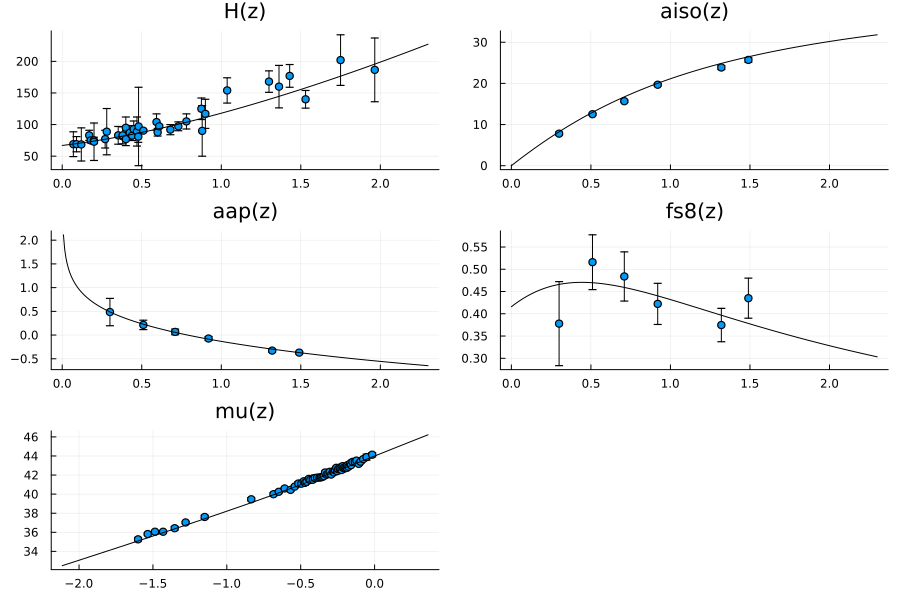

In [14]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,title="H(z)", legend=false)
p1 = plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,title="aiso(z)", legend=false)
p2 = plot(datafs8.z, log10.(dataDESI.data_dhdm), yerr=aap_err, seriestype=:scatter, title="aap(z)", legend=false)
p3 = plot(datafs8.z, dataDESI.data_fs8, yerr=fs8_err, seriestype=:scatter, title="fs8(z)", legend=false)
p4 = plot(log10.(datamu.z), datamu.data, yerr=mu_err, seriestype=:scatter, title="mu(z)", legend=false)

plot!(p0, z_integ1, hz_from_ez(z_integ1, cosmo1.cpar.h, ez_test), color=:black)
plot!(p1, z_integ1, a_iso(z_integ1, cosmo1.cpar.h, rd_red, ez_test), color=:black)
plot!(p2, z_integ1, log10.(a_ap(z_integ1, cosmo1.cpar.h, ez_test)), color=:black)
plot!(p3, z_integ1, fs8_from_ez(z_integ1, cosmo1.cpar.Ωm, cosmo1.cpar.σ8, cosmo1.cpar.h, ez_test), color=:black)
plot!(p4, log10.(z_integ1), mu(z_integ1, z_integ1, cosmo1.cpar.h, -19.1, ez_test), color=:black)

plot(p0, p1, p2, p3, p4, layout=(3,2), size=(900,600))

In [15]:
fs8df = DataFrame(
    data = datafs8.data,
    z = datafs8.z,
    err = datafs8.err
)

CSV.write("fs8_data.csv", fs8df)

"fs8_data.csv"

## LCDM analysis

In [16]:
data_obs = [datahz.data; dataDESI.data; datamu.data];
z_obs = [datahz.z; dataDESI.z; datamu.z];
covariance_obs = BlockDiagonal([datahz.cov, dataDESI.cov, datamu.cov]);

In [17]:
@model function LCDM_model(data, data_cov)
    # Priors
    omegam_pr ~ omegam_dist
    h0_pr ~ h0_dist
    s8_pr ~ s8_dist
    rd_pr ~ rd_dist
    M_pr ~ M_dist

    # Create cosmology
    cosmo_pr = LimberJack.Cosmology(Ωm=cosmo1.cpar.Ωm, Ωb=cosmo1.cpar.Ωb, h=cosmo1.cpar.h, σ8=s8_pr);
    
    # Model predictions
    ez_model = Ez(cosmo_pr, z_integ1)
    hz_model := hz_from_ez(z_integ1, h0_pr, ez_model)
    dv_rd_model := a_iso(z_integ1, h0_pr, rd_pr, ez_model) 
    dh_dm_model := a_ap(z_integ1, h0_pr, ez_model)
    fs8_model := fs8_from_ez(z_integ1, omegam_pr, s8_pr, h0_pr, ez_model)
    mu_model := mu(z_integ1, z_integ1, h0_pr, M_pr, ez_model)

    # Create interpolators
    hz_itp = LinearInterpolation(z_integ1, hz_model, extrapolation_bc=Line())
    dvrd_itp = LinearInterpolation(z_integ1, dv_rd_model, extrapolation_bc=Line())
    dhdm_itp = LinearInterpolation(z_integ1, dh_dm_model, extrapolation_bc=Line())
    fs8_itp = LinearInterpolation(z_integ1, fs8_model, extrapolation_bc=Line())
    mu_itp = LinearInterpolation(z_integ1, mu_model, extrapolation_bc=Line())

    hz_theory := hz_itp(datahz.z)
    dvrd_theory := dvrd_itp(datafs8.z)
    dhdm_theory := dhdm_itp(datafs8.z)
    fs8_theory := fs8_itp(datafs8.z)
    mu_theory := mu_itp(datamu.z)

    DESI_theory = vec(permutedims(hcat(dvrd_theory, dhdm_theory, fs8_theory)))
    theory = [hz_theory; DESI_theory; mu_theory]

    # Likelihood
    data ~ MvNormal(theory, data_cov)
end

LCDM_model (generic function with 2 methods)

In [18]:
cond_LCDM_model = LCDM_model(data_obs, covariance_obs)
chain_LCDM = sample(cond_LCDM_model, NUTS(30, 0.7), 500)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.025
└ @ Turing.Inference /Users/vis/.julia/packages/Turing/QN7BL/src/mcmc/hmc.jl:212
Sampling   1%|▎                                         |  ETA: 1:10:51
Sampling   1%|▌                                         |  ETA: 0:35:32
Sampling   2%|▋                                         |  ETA: 0:26:59
Sampling   2%|▉                                         |  ETA: 0:20:29
Sampling   3%|█▏                                        |  ETA: 0:17:03
Sampling   3%|█▎                                        |  ETA: 0:17:24
Sampling   4%|█▌                                        |  ETA: 0:15:34
Sampling   4%|█▊                                        |  ETA: 0:15:08
Sampling   5%|█▉                                        |  ETA: 0:14:32
Sampling   5%|██▏                                       |  ETA: 0:13:19
Sampling   6%|██▍                                       |  ETA: 0:12:06
Sampling   6%

Chains MCMC chain (500×1630×1 Array{Float64, 3}):

Iterations        = 31:1:530
Number of chains  = 1
Samples per chain = 500
Wall duration     = 738.78 seconds
Compute duration  = 738.78 seconds
parameters        = omegam_pr, h0_pr, s8_pr, rd_pr, M_pr, hz_model[1], hz_model[2], hz_model[3], hz_model[4], hz_model[5], hz_model[6], hz_model[7], hz_model[8], hz_model[9], hz_model[10], hz_model[11], hz_model[12], hz_model[13], hz_model[14], hz_model[15], hz_model[16], hz_model[17], hz_model[18], hz_model[19], hz_model[20], hz_model[21], hz_model[22], hz_model[23], hz_model[24], hz_model[25], hz_model[26], hz_model[27], hz_model[28], hz_model[29], hz_model[30], hz_model[31], hz_model[32], hz_model[33], hz_model[34], hz_model[35], hz_model[36], hz_model[37], hz_model[38], hz_model[39], hz_model[40], hz_model[41], hz_model[42], hz_model[43], hz_model[44], hz_model[45], hz_model[46], hz_model[47], hz_model[48], hz_model[49], hz_model[50], hz_model[51], hz_model[52], hz_model[53], hz_model[54],

In [19]:
lcdm_df_1 = DataFrame(chain_LCDM)
CSV.write("lcdm_chains_normal.csv", lcdm_df_1)

"lcdm_chains_normal.csv"

In [20]:
# lcdm chains
hzdata_lcdm = group(chain_LCDM, :hz_model).value.data[:,:,1];
aisodata_lcdm = group(chain_LCDM, :dv_rd_model).value.data[:,:,1];
aapdata_lcdm = group(chain_LCDM, :dh_dm_model).value.data[:,:,1];
fs8data_lcdm = group(chain_LCDM, :fs8_model).value.data[:,:,1];
mudata_lcdm = group(chain_LCDM, :mu_model).value.data[:,:,1];

# mean and standard deviation - lcdm
hz_lcdm_m, hz_lcdm_s = mean(hzdata_lcdm, dims=1), std(hzdata_lcdm, dims=1); 
aiso_lcdm_m, aiso_lcdm_s = mean(aisodata_lcdm, dims=1), std(aisodata_lcdm, dims=1);
aap_lcdm_m, aap_lcdm_s = mean(aapdata_lcdm, dims=1), std(aapdata_lcdm, dims=1); 
fs8_lcdm_m, fs8_lcdm_s = mean(fs8data_lcdm, dims=1), std(fs8data_lcdm, dims=1); 
mu_lcdm_m, mu_lcdm_s = mean(mudata_lcdm, dims=1), std(mudata_lcdm, dims=1); 

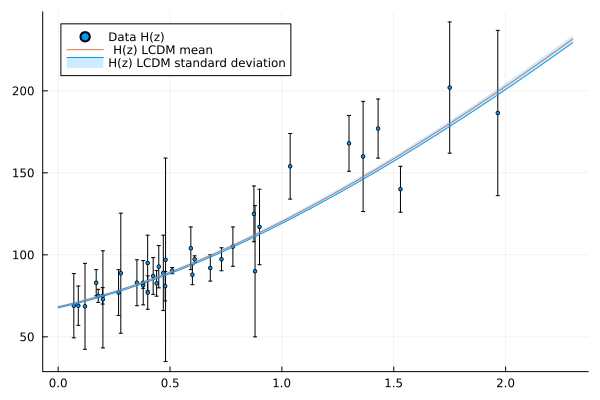

In [21]:
plot(datahz.z, datahz.data, yerr=hz_err, label="Data H(z)", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(hz_lcdm_m), label=" H(z) LCDM mean")
plot!(z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")

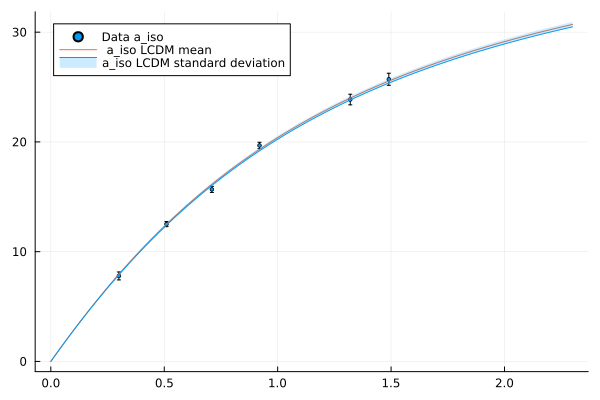

In [22]:
plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, label="Data a_iso", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(aiso_lcdm_m), label=" a_iso LCDM mean")
plot!(z_integ1, vec(aiso_lcdm_m .- aiso_lcdm_s),  fillrange = vec(aiso_lcdm_m .+ aiso_lcdm_s), fillalpha=0.2, c=1, label="a_iso LCDM standard deviation")

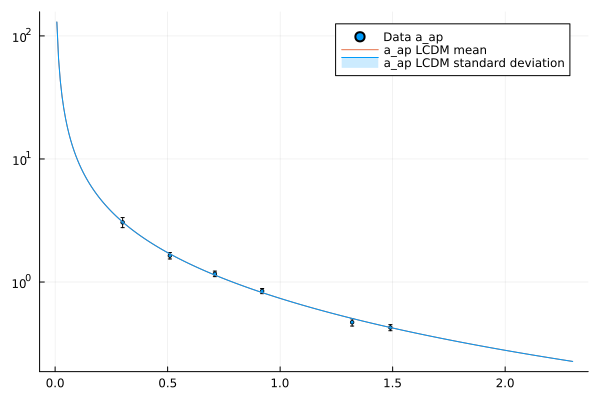

In [23]:
plot(datafs8.z, dataDESI.data_dhdm, yerr=aap_err, label="Data a_ap", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(aap_lcdm_m), label="a_ap LCDM mean")
plot!(z_integ1, vec(aap_lcdm_m .- aap_lcdm_s),  fillrange = vec(aap_lcdm_m .+ aap_lcdm_s), fillalpha=0.2, c=1, yscale=:log10, label="a_ap LCDM standard deviation")

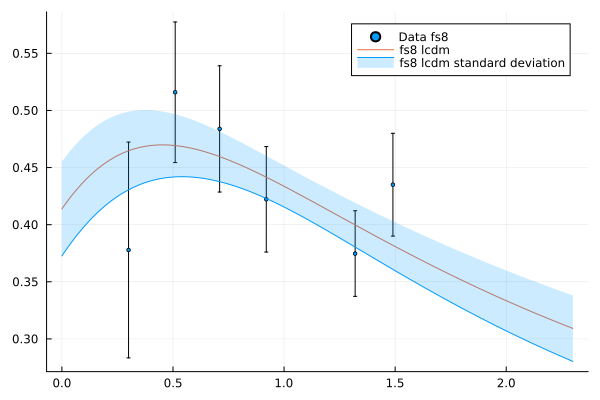

In [24]:
plot(datafs8.z, datafs8.data, yerr=fs8_err, label="Data fs8", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(fs8_lcdm_m), label="fs8 lcdm")
plot!(z_integ1, vec(fs8_lcdm_m .- fs8_lcdm_s),  fillrange = vec(fs8_lcdm_m .+ fs8_lcdm_s), fillalpha=0.2, c=1, label="fs8 lcdm standard deviation")

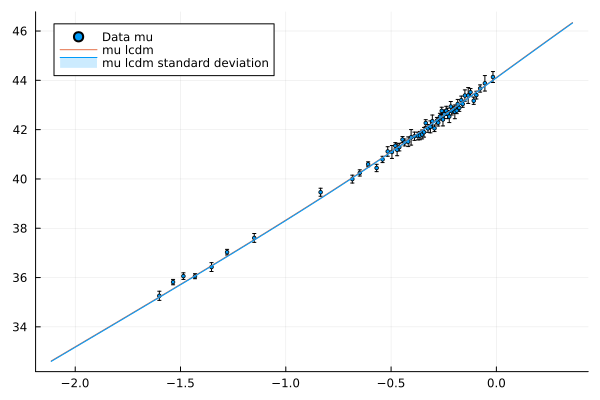

In [25]:
plot(log10.(datamu.z), datamu.data, yerr=mu_err, label="Data mu", ms=2, seriestype=:scatter)
plot!(log10.(z_integ1), vec(mu_lcdm_m), label="mu lcdm")
plot!(log10.(z_integ1), vec(mu_lcdm_m .- mu_lcdm_s),  fillrange = vec(mu_lcdm_m .+ mu_lcdm_s), fillalpha=0.2, c=1, label="mu lcdm standard deviation")
# plot(datamu.z, datamu.data, yerr=mu_err, label="Data mu", ms=2, seriestype=:scatter)
# plot!(z_integ1, vec(mu_lcdm_m), label="mu lcdm")
# plot!(z_integ1, vec(mu_lcdm_m .- mu_lcdm_s),  fillrange = vec(mu_lcdm_m .+ mu_lcdm_s), fillalpha=0.2, c=1, label="mu lcdm standard deviation")

## GP analysis

In [26]:
zlat = range(0, 2.3, length=15); # latent variable space
z_integ = range(0.0, 2.3, length=300);; # integral variable space

In [27]:
function model_latent_GP(eta, l, v; omega_m=cosmo1.cpar.Ωm, sigma_8=cosmo1.cpar.σ8, h_0 = cosmo1.cpar.h,
                         x=zlat, z=z_obs, data_cov=covariance_obs)
    # Dimensions of predictors .
    kernel = sqexp_cov_fn(x; eta=eta, l=l)
    cpar = CosmoPar(Ωm=omega_m,  Ωb=cosmo1.cpar.Ωb, h=h_0, σ8=sigma_8)
    mean_ex = Ez(cpar, x)
    # a latent GP is carried out using a Wiener filter
    ex = latent_GP(mean_ex, v, kernel)
    # transforms hx from x space to z space
    ez =  conditional(x, z, ex, sqexp_cov_fn;
                     eta=eta, l=l)
    return ex, ez
end

model_latent_GP (generic function with 1 method)

##### hx is the GP realisation of the hubble parameter. hz transforms hx from the latent space to another parameter space (integral or observation).

In [28]:
N_samples = 100
# data parameter space conditional
exs1=zeros(N_samples, 15) #latent variable chain
ezs1=zeros(N_samples, length(z_obs)) #observed variable chain
# pick 100 random hyperparameter combinations, and compute the GP realisation of them in both latent and conditional space.
for i in 1:N_samples
    v = rand(MvNormal(zeros(length(zlat)), ones(length(zlat))))
    exs1[i, :], ezs1[i, :] = model_latent_GP(0.2, 0.3, v)
end
y_m1, y_s1 = mean(ezs1, dims=1), std(ezs1, dims=1); #observed space
gp_m1, gp_s1 = mean(exs1, dims=1), std(exs1, dims=1); #latent space


In [29]:
# integral parameter space conditional
exs2=zeros(N_samples, length(zlat))
ezs2=zeros(N_samples, length(z_integ))
hz_pr=zeros(N_samples, length(z_integ))
aiso_pr=zeros(N_samples, length(z_integ))
aap_pr=zeros(N_samples, length(z_integ))
fs8_pr=zeros(N_samples, length(z_integ))
mu_pr=zeros(N_samples, length(z_integ))

for i in 1:N_samples
    v = rand(MvNormal(zeros(length(zlat)), ones(length(zlat))))
    h_pr = rand(h0_dist)
    s8_pr = rand(s8_dist)
    omegam_pr = rand(omegam_dist)
    rd_pr = rand(rd_dist)
    M_pr = rand(M_dist)

    exs2[i, :], ezs2[i, :] = model_latent_GP(0.1, 0.3, v; z=z_integ, sigma_8=s8_pr)
    hz_pr[i, :] = hz_from_ez(z_integ, h_pr, ezs2[i, :])
    aiso_pr[i, :] = a_iso(z_integ, h_pr, rd_pr, ezs2[i, :])
    aap_pr[i, :] = a_ap(z_integ, h_pr, ezs2[i, :])
    fs8_pr[i, :] = fs8_from_ez(z_integ, omegam_pr, s8_pr, h_pr, ezs2[i, :])
    mu_pr[i, :] = mu(z_integ1, z_integ1, h_pr, M_pr, ezs2[i, :])
end


y_m2, y_s2 = mean(ezs2, dims=1), std(ezs2, dims=1); #integral space
gp_m2, gp_s2 = mean(exs2, dims=1), std(exs2, dims=1); #latent space

hz_m2, hz_s2 = mean(hz_pr, dims=1), std(hz_pr, dims=1); 
aiso_m2, aiso_s2 = mean(aiso_pr, dims=1), std(aiso_pr, dims=1); 
aap_m2, aap_s2 = mean(aap_pr, dims=1), std(aap_pr, dims=1);
fs8_m2, fs8_s2 = mean(fs8_pr, dims=1), std(fs8_pr, dims=1);
mu_m2, mu_s2 = mean(mu_pr, dims=1), std(mu_pr, dims=1);
# prior model predictions
hz_itp2 = LinearInterpolation(z_integ, vec(hz_m2), extrapolation_bc=Line());
aiso_itp2 = LinearInterpolation(z_integ, vec(aiso_m2), extrapolation_bc=Line());
aap_itp2 = LinearInterpolation(z_integ, vec(aap_m2), extrapolation_bc=Line());
fs8_itp2 = LinearInterpolation(z_integ, vec(fs8_m2), extrapolation_bc=Line());
mu_itp2 = LinearInterpolation(z_integ, vec(mu_m2), extrapolation_bc=Line());


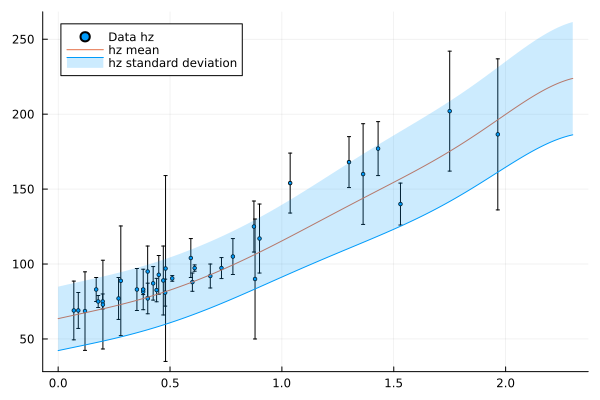

In [30]:
# integral space hz plot
plot(datahz.z, datahz.data, yerr=hz_err, label="Data hz", ms=2, seriestype=:scatter)
plot!(z_integ, vec(hz_m2), label="hz mean")
plot!(z_integ, vec(hz_m2 .- hz_s2),  fillrange = vec(hz_m2 .+ hz_s2), fillalpha=0.2, c=1, label="hz standard deviation")


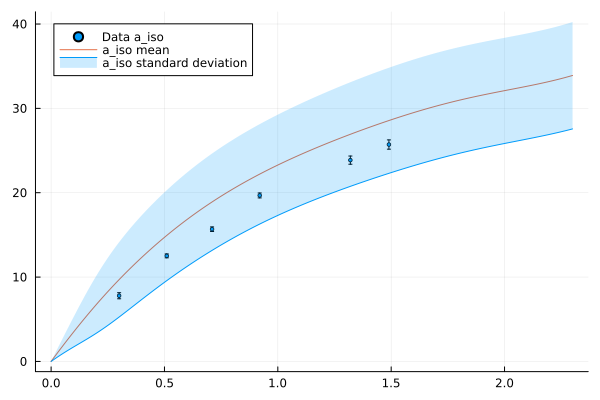

In [31]:
# integral space aiso plot
plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, label="Data a_iso", ms=2, seriestype=:scatter)
plot!(z_integ, vec(aiso_m2), label="a_iso mean")
plot!(z_integ, vec(aiso_m2 .- aiso_s2),  fillrange = vec(aiso_m2 .+ aiso_s2), fillalpha=0.2, c=1, label="a_iso standard deviation")

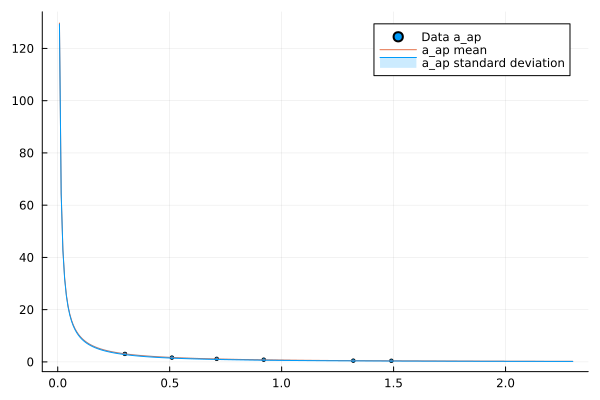

In [32]:
# plotting chi data 
plot(datafs8.z, dataDESI.data_dhdm, yerr=aap_err, label="Data a_ap", ms=2, seriestype=:scatter)
plot!(z_integ, vec(aap_m2), label="a_ap mean")
plot!(z_integ, vec(aap_m2 .- aap_s2),  fillrange = vec(aap_m2 .+ aap_s2), fillalpha=0.2, c=1, label="a_ap standard deviation")


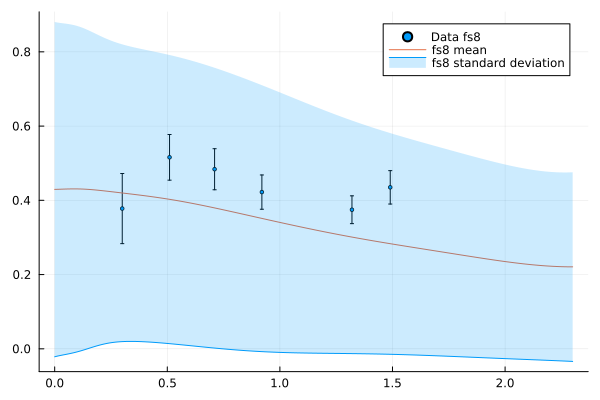

In [33]:
# plotting fs8 data 
plot(datafs8.z, datafs8.data, yerr=fs8_err, label="Data fs8", ms=2, seriestype=:scatter)
plot!(z_integ, vec(fs8_m2), label="fs8 mean")
plot!(z_integ, vec(fs8_m2 .- fs8_s2),  fillrange = vec(fs8_m2 .+ fs8_s2), fillalpha=0.2, c=1, label="fs8 standard deviation")


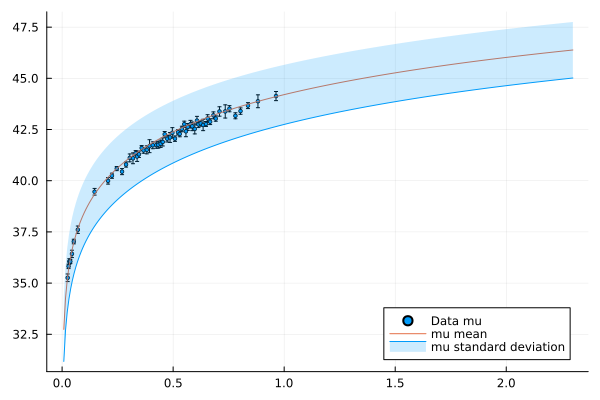

In [34]:
# plotting supernovae data 
plot(datamu.z, datamu.data, yerr=mu_err, label="Data mu", ms=2, seriestype=:scatter)
plot!(z_integ, vec(mu_m2), label="mu mean")
plot!(z_integ, vec(mu_m2 .- mu_s2),  fillrange = vec(mu_m2 .+ mu_s2), fillalpha=0.2, c=1, label="mu standard deviation")

In [35]:
@model function stats_model(y, data_cov; int_grid=z_integ, X=zlat, data_x=z_obs)
    # Priors, parameters
    eta2 = 0.2
    l2 = 1.0
    v_po ~ MvNormal(zeros(length(X)), ones(length(X)))
    omegam_po ~ omegam_dist
    s8_po ~ s8_dist
    h_po ~ h0_dist
    r_po ~ rd_dist
    M_po ~ M_dist
    
    kernel = sqexp_cov_fn(X, eta=eta2, l=l2)
    cpar = CosmoPar(Ωm=cosmo1.cpar.Ωm, Ωb=cosmo1.cpar.Ωb, h=cosmo1.cpar.h, σ8=s8_po)
    mean_ez = Ez(cpar, X)
    ez_latent = latent_GP(mean_ez, v_po, kernel)
    ez_gp = conditional(X, int_grid, ez_latent, sqexp_cov_fn; eta=eta2, l=l2) # converting from latent space to integral space
    
    # sampling over parameters
    hz_mod := hz_from_ez(int_grid, h_po, ez_gp);
    aiso_mod := a_iso(int_grid, h_po, r_po, ez_gp);
    aap_mod := a_ap(int_grid, h_po, ez_gp);
    fs8_mod := fs8_from_ez(int_grid, omegam_po, s8_po, h_po, ez_gp);
    mu_mod := mu(int_grid, int_grid, h_po, M_po, ez_gp);

    hz_interp = LinearInterpolation(int_grid, hz_mod, extrapolation_bc=Line())
    aiso_interp = LinearInterpolation(int_grid, aiso_mod, extrapolation_bc=Line())
    aap_interp = LinearInterpolation(int_grid, aap_mod, extrapolation_bc=Line())
    fs8_interp = LinearInterpolation(int_grid, fs8_mod, extrapolation_bc=Line())
    mu_interp = LinearInterpolation(int_grid, mu_mod, extrapolation_bc=Line())

    hdata := hz_interp(datahz.z)
    aisodata := aiso_interp(datafs8.z)
    aapdata := aap_interp(datafs8.z)
    fs8data := fs8_interp(datafs8.z)
    mudata := mu_interp(datamu.z)

    DESIdata = vec(permutedims(hcat(aisodata, aapdata, fs8data)))
    datay = [hdata;DESIdata;mudata]

    y ~ MvNormal(datay, data_cov) 

end

stats_model (generic function with 2 methods)

In [36]:
chain_gp = sample(stats_model(data_obs, covariance_obs), NUTS(30, 0.7), 500)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.000390625
└ @ Turing.Inference /Users/vis/.julia/packages/Turing/QN7BL/src/mcmc/hmc.jl:212
Sampling   1%|▎                                         |  ETA: 1:02:15
Sampling   1%|▌                                         |  ETA: 0:31:42
Sampling   2%|▋                                         |  ETA: 0:34:16
Sampling   2%|▉                                         |  ETA: 1:15:13
Sampling   3%|█▏                                        |  ETA: 1:15:38
Sampling   3%|█▎                                        |  ETA: 1:30:39
Sampling   4%|█▌                                        |  ETA: 1:34:39
Sampling   4%|█▊                                        |  ETA: 1:30:17
Sampling   5%|█▉                                        |  ETA: 1:41:51
Sampling   5%|██▏                                       |  ETA: 1:41:32
Sampling   6%|██▍                                       |  ETA: 1:38:43
Samplin

Chains MCMC chain (500×1645×1 Array{Float64, 3}):

Iterations        = 31:1:530
Number of chains  = 1
Samples per chain = 500
Wall duration     = 5190.96 seconds
Compute duration  = 5190.96 seconds
parameters        = v_po[1], v_po[2], v_po[3], v_po[4], v_po[5], v_po[6], v_po[7], v_po[8], v_po[9], v_po[10], v_po[11], v_po[12], v_po[13], v_po[14], v_po[15], omegam_po, s8_po, h_po, r_po, M_po, hz_mod[1], hz_mod[2], hz_mod[3], hz_mod[4], hz_mod[5], hz_mod[6], hz_mod[7], hz_mod[8], hz_mod[9], hz_mod[10], hz_mod[11], hz_mod[12], hz_mod[13], hz_mod[14], hz_mod[15], hz_mod[16], hz_mod[17], hz_mod[18], hz_mod[19], hz_mod[20], hz_mod[21], hz_mod[22], hz_mod[23], hz_mod[24], hz_mod[25], hz_mod[26], hz_mod[27], hz_mod[28], hz_mod[29], hz_mod[30], hz_mod[31], hz_mod[32], hz_mod[33], hz_mod[34], hz_mod[35], hz_mod[36], hz_mod[37], hz_mod[38], hz_mod[39], hz_mod[40], hz_mod[41], hz_mod[42], hz_mod[43], hz_mod[44], hz_mod[45], hz_mod[46], hz_mod[47], hz_mod[48], hz_mod[49], hz_mod[50], hz_mod[51], hz

In [37]:
gp_df_1 = DataFrame(chain_gp)
CSV.write("gp_chains_normal.csv", gp_df_1)

"gp_chains_normal.csv"

In [38]:
# data posterior gp chains
hdata_p = group(chain_gp, :hz_mod).value.data[:,:,1];
aisodata_p = group(chain_gp, :aiso_mod).value.data[:,:,1];
aapdata_p =  group(chain_gp, :aap_mod).value.data[:,:,1];
fs8data_p =  group(chain_gp, :fs8_mod).value.data[:,:,1];
mudata_p =  group(chain_gp, :mu_mod).value.data[:,:,1];

# parameter chains
v_p = group(chain_gp, :v_po).value.data[:, :, 1];
omegam_p = group(chain_gp, :omegam_po).value.data[:, :, 1];
s8_p = group(chain_gp, :s8_po).value.data[:, :, 1];

# data mean / standard dev.
hpmean, hps = mean(hdata_p, dims=1), std(hdata_p, dims=1);
aisopmean, aisops = mean(aisodata_p, dims=1), std(aisodata_p, dims=1);
aappmean, aapps = mean(aapdata_p, dims=1), std(aapdata_p, dims=1);
fs8pmean, fs8ps = mean(fs8data_p, dims=1), std(fs8data_p, dims=1);
mupmean, mups = mean(mudata_p, dims=1), std(mudata_p, dims=1);

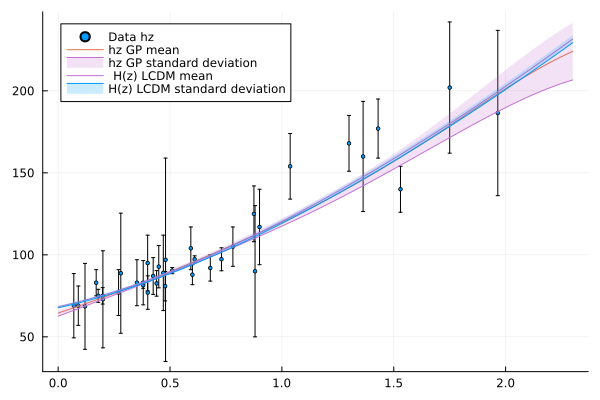

In [39]:
plot(datahz.z, datahz.data, yerr=hz_err, label="Data hz", ms=2, seriestype=:scatter)
plot!(z_integ1, vec(hpmean), label="hz GP mean")
plot!(z_integ1, vec(hpmean .- hps),  fillrange = vec(hpmean .+ hps), fillalpha=0.2, c=4, label="hz GP standard deviation")
plot!(z_integ1, vec(hz_lcdm_m), label=" H(z) LCDM mean")
plot!(z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")

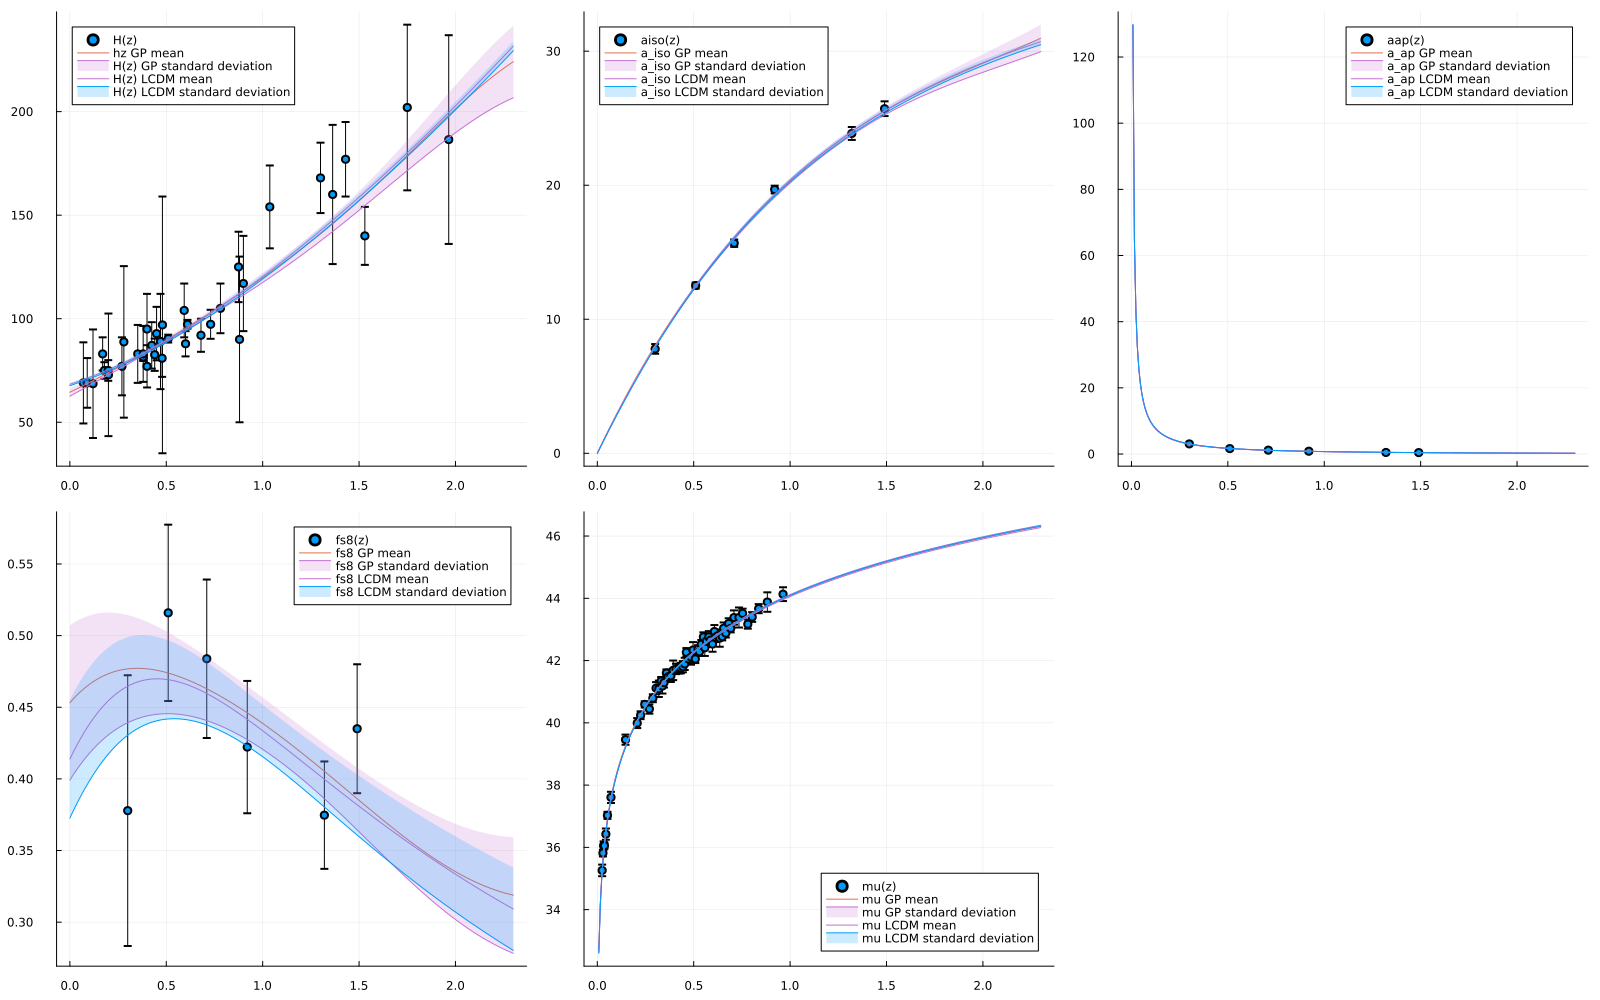

In [40]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,label="H(z)")
p1 = plot(datafs8.z, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,label="aiso(z)")
p2 = plot(datafs8.z, dataDESI.data_dhdm, yerr=aap_err, seriestype=:scatter, label="aap(z)")
p3 = plot(datafs8.z, datafs8.data, yerr=fs8_err, seriestype=:scatter, label="fs8(z)")
p4 = plot(datamu.z, datamu.data, yerr=mu_err, seriestype=:scatter, label="mu(z)")


plot!(p0, z_integ1, vec(hpmean), label="hz GP mean")
plot!(p0, z_integ1, vec(hpmean .- hps),  fillrange = vec(hpmean .+ hps), fillalpha=0.2, c=4, label="H(z) GP standard deviation")
plot!(p0, z_integ1, vec(hz_lcdm_m), label="H(z) LCDM mean")
plot!(p0, z_integ1, vec(hz_lcdm_m .- hz_lcdm_s),  fillrange = vec(hz_lcdm_m .+ hz_lcdm_s), fillalpha=0.2, c=1, label="H(z) LCDM standard deviation")


plot!(p1, z_integ1, vec(aisopmean), label="a_iso GP mean")
plot!(p1, z_integ1, vec(aisopmean .- aisops),  fillrange = vec(aisopmean .+ aisops), fillalpha=0.2, c=4, label="a_iso GP standard deviation")
plot!(p1, z_integ1, vec(aiso_lcdm_m), label="a_iso LCDM mean")
plot!(p1, z_integ1, vec(aiso_lcdm_m .- aiso_lcdm_s),  fillrange = vec(aiso_lcdm_m .+ aiso_lcdm_s), fillalpha=0.2, c=1, label="a_iso LCDM standard deviation")


plot!(p2, z_integ1, vec(aappmean), label="a_ap GP mean")
plot!(p2, z_integ1, vec(aappmean .- aapps),  fillrange = vec(aappmean .+ aapps), fillalpha=0.2, c=4, label="a_ap GP standard deviation")
plot!(p2, z_integ1, vec(aap_lcdm_m), label="a_ap LCDM mean")
plot!(p2, z_integ1, vec(aap_lcdm_m .- aap_lcdm_s),  fillrange = vec(aap_lcdm_m .+ aap_lcdm_s), fillalpha=0.2, c=1, label="a_ap LCDM standard deviation")


plot!(p3, z_integ1, vec(fs8pmean), label="fs8 GP mean")
plot!(p3, z_integ1, vec(fs8pmean .- fs8ps),  fillrange = vec(fs8pmean .+ fs8ps), fillalpha=0.2, c=4, label="fs8 GP standard deviation")
plot!(p3, z_integ1, vec(fs8_lcdm_m), label="fs8 LCDM mean")
plot!(p3, z_integ1, vec(fs8_lcdm_m .- fs8_lcdm_s),  fillrange = vec(fs8_lcdm_m .+ fs8_lcdm_s), fillalpha=0.2, c=1, label="fs8 LCDM standard deviation")


plot!(p4, z_integ1, vec(mupmean), label="mu GP mean")
plot!(p4, z_integ1, vec(mupmean .- mups),  fillrange = vec(mupmean .+ mups), fillalpha=0.2, c=4, label="mu GP standard deviation")
plot!(p4, z_integ1, vec(mu_lcdm_m), label="mu LCDM mean")
plot!(p4, z_integ1, vec(mu_lcdm_m .- mu_lcdm_s),  fillrange = vec(mu_lcdm_m .+ mu_lcdm_s), fillalpha=0.2, c=1, label="mu LCDM standard deviation")

plot(p0, p1, p2, p3, p4, layout=(2,3), size=(1600,1000))